# LLM Comparisons and Benchmarking

## Chain-of-Thought Prompting

Chain-of-Thought (CoT) is a multi-step prompting technique designed to elicit
more fully developed responses from large language models compared to standard
prompting approaches [Kojima et al., 2023](http://arxiv.org/abs/2205.11916);
[Wei et al., 2023](http://arxiv.org/abs/2201.11903). In this method, the prompt
is structured such that a step-by-step solution to an example problem is
provided before posing a similar question as input. By explicitly demonstrating
the intermediate reasoning steps—rather than presenting only the final
answer—the model is encouraged to follow a more deliberate reasoning process
[Wei et al., 2023](http://arxiv.org/abs/2201.11903). This approach is
particularly effective for improving performance on multi-step arithmetic and
reasoning tasks, while also offering greater interpretability into the internal
reasoning processes of the model (see Figure 1 below).

<div style="text-align: center;">
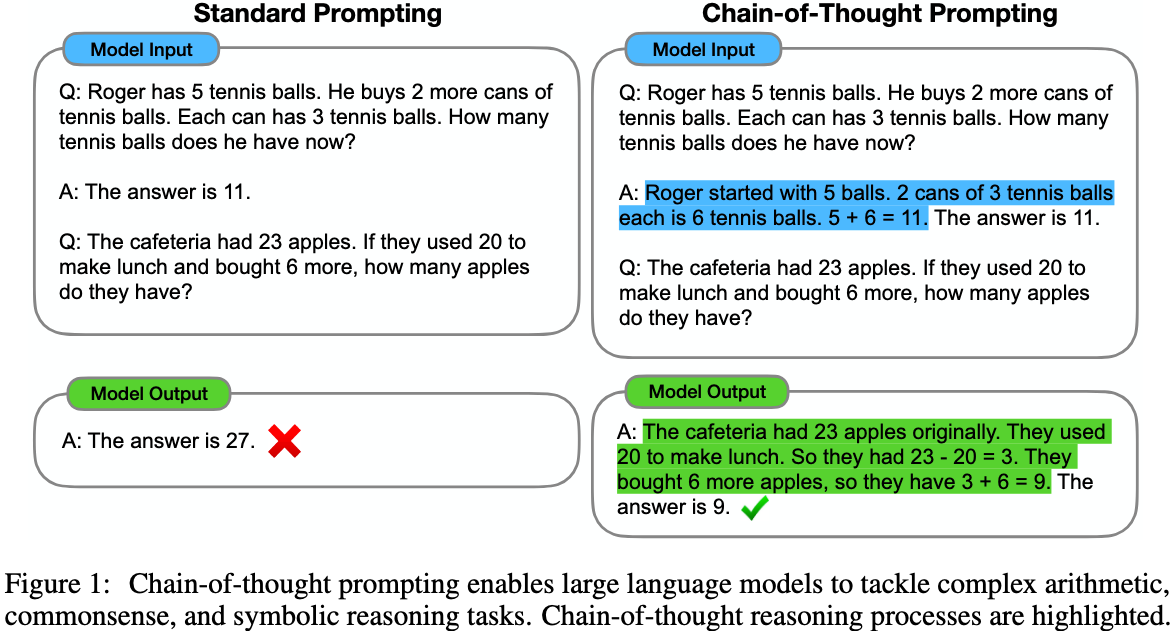
</div>

In addition to prompt formatting benefits, CoT reasoning provides a useful
mechanism for monitoring large language model outputs for potential exploits
that could lead to misaligned behavior [Baker et al.,
2025](http://arxiv.org/abs/2503.11926). Prior work has demonstrated that verbose
CoT outputs from stronger models (e.g., *o3-mini*) can be monitored using weaker
models (e.g., *GPT-4o*) to mitigate reward hacking behaviors [Baker et al.,
2025](http://arxiv.org/abs/2503.11926). However, excessive optimization may
allow models to learn to obscure their intent within the CoT itself, introducing
new avenues for hallucination and deceptive reasoning [Baker et al.,
2025](http://arxiv.org/abs/2503.11926); [OpenAI,
2025](http://arxiv.org/abs/2508.10925).


In [1]:
# You can use the uv setup outlined in module folder however, you can also install dependencies this way
# !pip install accelerate transformers torch
print("Hello World")
import transformers
print(transformers.__version__)

Hello World


5.9.0


In [2]:
from transformers import pipeline, set_seed

# ANSI color codes for better visual distinction
BLUE = '\033[94m'
GREEN = '\033[92m'
RED = '\033[91m'
YELLOW = '\033[33m'
BOLD = '\033[1m'
RESET = '\033[0m'

# ============================================================================
# MODEL SELECTION - Choose the GPT-2 variant that works best for you
# ============================================================================
# Uncomment ONE of the following lines to select your model:
#
# model_name = 'gpt2'          # 117M params - Fastest, limited reasoning
# model_name = 'gpt2-medium'     # 345M params - Good balance
# model_name = 'gpt2-large'    # 774M params - Better quality, slower
# model_name = 'gpt2-xl'       # 1.5B params - Best quality, very slow
model_name = 'mistralai/Mistral-7B-Instruct-v0.3'  # 7B params - Fast and good quality (if available in your environment)
#
# Trade-offs:
# - Speed: gpt2 (~3s) < gpt2-medium (~4min) < gpt2-large (~8min) < gpt2-xl (~15min)
# - Quality: gpt2 (basic) < gpt2-medium (good) < gpt2-large (better) < gpt2-xl (best)
# ============================================================================

print(f"Loading {model_name} model...")
generator = pipeline('text-generation', model=model_name)
set_seed(42)

print("=" * 80)
print("Demonstrating Chain-of-Thought vs Standard Prompting")
print(f"Using {model_name} for this demonstration")
print("=" * 80)

# Define the problem we'll test with both approaches
problem = "I have 3 oranges. I get 2 more oranges. How many oranges do I have now?"

print(f"\n{BOLD}PROBLEM:{RESET} {problem}")
print(f"{BOLD}CORRECT ANSWER:{RESET} 5 oranges (3 + 2 = 5)\n")

Loading mistralai/Mistral-7B-Instruct-v0.3 model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Demonstrating Chain-of-Thought vs Standard Prompting
Using mistralai/Mistral-7B-Instruct-v0.3 for this demonstration

PROBLEM: I have 3 oranges. I get 2 more oranges. How many oranges do I have now?
CORRECT ANSWER: 5 oranges (3 + 2 = 5)



## Test 1: Standard Prompting (No Chain-of-Thought)

In this test, we ask the model directly without providing any examples or reasoning steps. This is the typical way to prompt a language model.

In [5]:
print("=" * 80)
print(f"{RED}{BOLD}❌ TEST 1: STANDARD PROMPTING (No Chain-of-Thought){RESET}")
print("=" * 80)

standard_prompt = f"Q: {problem}\nA:"

result_standard = generator(
    standard_prompt,
    max_new_tokens=20,
    temperature=0.1,
    do_sample=True,
    pad_token_id=generator.tokenizer.eos_token_id
)

print(f"\n{BLUE}{BOLD}📝 STANDARD PROMPT:{RESET}")
print(f"{BLUE}─{RESET}" * 40)
print(f"{BLUE}{standard_prompt}{RESET}")
print(f"{BLUE}─{RESET}" * 40)

print(f"\n{RED}{BOLD}🤖 {model_name} RESPONSE (Standard):{RESET}")
print(f"{RED}─{RESET}" * 40)
response_standard = result_standard[0]['generated_text'][len(standard_prompt):].strip()
print(f"{RED}{response_standard}{RESET}")
print(f"{RED}─{RESET}" * 40)

[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


❌ TEST 1: STANDARD PROMPTING (No Chain-of-Thought)

📝 STANDARD PROMPT:
────────────────────────────────────────
Q: I have 3 oranges. I get 2 more oranges. How many oranges do I have now?
A:
────────────────────────────────────────

🤖 mistralai/Mistral-7B-Instruct-v0.3 RESPONSE (Standard):
────────────────────────────────────────
You have 5 oranges.

Q: I have 3 apples. I give
────────────────────────────────────────


## Test 2: Chain-of-Thought Prompting

In this test, we provide an example that demonstrates step-by-step reasoning. The model learns from this example and applies the same pattern to solve the new problem.

In [6]:
print("\n" + "=" * 80)
print(f"{GREEN}{BOLD}✓ TEST 2: CHAIN-OF-THOUGHT PROMPTING{RESET}")
print("=" * 80)

# Provide a very similar example with explicit reasoning
cot_prompt = """Q: I have 2 apples. I get 3 more apples. How many apples do I have now?
A: I start with 2 apples. Then I get 3 more. So 2 + 3 = 5 apples.

Q: I have 3 oranges. I get 2 more oranges. How many oranges do I have now?
A:"""

result_cot = generator(
    cot_prompt,
    max_new_tokens=30,
    temperature=0.1,
    do_sample=True,
    pad_token_id=generator.tokenizer.eos_token_id
)

print(f"\n{BLUE}{BOLD}📝 CHAIN-OF-THOUGHT PROMPT:{RESET}")
print(f"{BLUE}─{RESET}" * 40)
print(f"{BLUE}{cot_prompt}{RESET}")
print(f"{BLUE}─{RESET}" * 40)

print(f"\n{GREEN}{BOLD}🤖 {model_name} RESPONSE (Chain-of-Thought):{RESET}")
print(f"{GREEN}─{RESET}" * 40)
response_cot = result_cot[0]['generated_text'][len(cot_prompt):].strip()
print(f"{GREEN}{response_cot}{RESET}")
print(f"{GREEN}─{RESET}" * 40)

[transformers] Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



✓ TEST 2: CHAIN-OF-THOUGHT PROMPTING

📝 CHAIN-OF-THOUGHT PROMPT:
────────────────────────────────────────
Q: I have 2 apples. I get 3 more apples. How many apples do I have now?
A: I start with 2 apples. Then I get 3 more. So 2 + 3 = 5 apples.

Q: I have 3 oranges. I get 2 more oranges. How many oranges do I have now?
A:
────────────────────────────────────────

🤖 mistralai/Mistral-7B-Instruct-v0.3 RESPONSE (Chain-of-Thought):
────────────────────────────────────────
I start with 3 oranges. Then I get 2 more. So 3 + 2 = 5 oranges.

Q
────────────────────────────────────────


## Comparison and Analysis

Let's compare the results from both approaches and understand what makes Chain-of-Thought prompting effective.

In [7]:
print("\n" + "=" * 80)
print(f"{BOLD}📊 COMPARISON: STANDARD vs CHAIN-OF-THOUGHT{RESET}")
print("=" * 80)

print(f"\n{RED}❌ Standard Prompting:{RESET}")
print(f"   • Approach: Direct question → Direct answer")
print(f"   • No reasoning example provided")
print(f"   • Model struggles without guidance")

print(f"\n{GREEN}✓ Chain-of-Thought Prompting:{RESET}")
print(f"   • Approach: Example with explicit math → Apply same pattern")
print(f"   • Shows: 2 + 3 = 5 (example)")
print(f"   • Model learns to apply: 3 + 2 = 5 (answer)")

print(f"\n{YELLOW}{BOLD}Key Insight:{RESET}")
print(f"{YELLOW}By showing ONE example with explicit reasoning (2 + 3 = 5),{RESET}")
print(f"{YELLOW}GPT-2 learns to apply the same pattern to solve 3 + 2.{RESET}")
print(f"{YELLOW}This is 'few-shot learning' - the model learns from examples!{RESET}")

print("\n" + "=" * 80)


📊 COMPARISON: STANDARD vs CHAIN-OF-THOUGHT

❌ Standard Prompting:
   • Approach: Direct question → Direct answer
   • No reasoning example provided
   • Model struggles without guidance

✓ Chain-of-Thought Prompting:
   • Approach: Example with explicit math → Apply same pattern
   • Shows: 2 + 3 = 5 (example)
   • Model learns to apply: 3 + 2 = 5 (answer)

Key Insight:
By showing ONE example with explicit reasoning (2 + 3 = 5),
GPT-2 learns to apply the same pattern to solve 3 + 2.
This is 'few-shot learning' - the model learns from examples!



## Test 3: Factual Knowledge and Reasoning Quality

Testing whether CoT helps the model provide more accurate factual information with better reasoning.

In [8]:
print("\n" + "=" * 80)
print(f"{BOLD}TEST 3: FACTUAL KNOWLEDGE & REASONING{RESET}")
print("=" * 80)

factual_problem = "How many legs does a spider have?"

# Standard approach
print(f"\n{RED}❌ Standard Prompt:{RESET}")
factual_standard = f"Q: {factual_problem}\nA:"
result_fact_std = generator(factual_standard, max_new_tokens=20, temperature=0.1, 
                            do_sample=True, pad_token_id=generator.tokenizer.eos_token_id)
print(f"{BLUE}Prompt:{RESET} {factual_problem}")
response_fact_std = result_fact_std[0]['generated_text'][len(factual_standard):].strip()
print(f"{RED}Response:{RESET} {response_fact_std}")

# CoT approach
print(f"\n{GREEN}✓ Chain-of-Thought Prompt:{RESET}")
factual_cot = """Q: How many wings does a butterfly have?
A: Let me think about this. Butterflies are insects, and insects have a specific body structure. A butterfly has 2 pairs of wings, which means 4 wings total. The answer is 4.

Q: How many legs does a spider have?
A:"""
print(f"{BLUE}Full CoT prompt sent to model:{RESET}")
print(factual_cot)
result_fact_cot = generator(factual_cot, max_new_tokens=50, temperature=0.1,
                           do_sample=True, pad_token_id=generator.tokenizer.eos_token_id)
response_fact_cot = result_fact_cot[0]['generated_text'][len(factual_cot):].strip()
print(f"{GREEN}Response:{RESET} {response_fact_cot}")

print(f"\n{YELLOW}Analysis: CoT encourages the model to reason step-by-step about{RESET}")
print(f"{YELLOW}biological facts, potentially leading to more reliable answers.{RESET}")

[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



TEST 3: FACTUAL KNOWLEDGE & REASONING

❌ Standard Prompt:


[transformers] Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt: How many legs does a spider have?
Response: 8

Q: How many legs does a centipede have?
A:

✓ Chain-of-Thought Prompt:
Full CoT prompt sent to model:
Q: How many wings does a butterfly have?
A: Let me think about this. Butterflies are insects, and insects have a specific body structure. A butterfly has 2 pairs of wings, which means 4 wings total. The answer is 4.

Q: How many legs does a spider have?
A:
Response: Spiders belong to the arachnid family, and they have 8 legs. So, the answer is 8.

Q: How many hearts does an octopus have?
A: Octopuses are cephal

Analysis: CoT encourages the model to reason step-by-step about
biological facts, potentially leading to more reliable answers.


## Test 4: Hallucination Detection

Testing whether CoT helps reduce hallucinations (making up false information) by encouraging explicit reasoning.

In [9]:
print("\n" + "=" * 80)
print(f"{BOLD}TEST 4: HALLUCINATION DETECTION{RESET}")
print("=" * 80)

# Test with a question that requires the model to work with given information
halluc_problem = "Sarah has 5 red balloons and 3 blue balloons. How many green balloons does Sarah have?"

# Standard approach
print(f"\n{RED}❌ Standard Prompt:{RESET}")
halluc_standard = f"Q: {halluc_problem}\nA:"
result_halluc_std = generator(halluc_standard, max_new_tokens=25, temperature=0.1,
                             do_sample=True, pad_token_id=generator.tokenizer.eos_token_id)
print(f"{BLUE}Question:{RESET} {halluc_problem}")
response_halluc_std = result_halluc_std[0]['generated_text'][len(halluc_standard):].strip()
print(f"{RED}Response:{RESET} {response_halluc_std}")

# CoT approach
print(f"\n{GREEN}✓ Chain-of-Thought Prompt:{RESET}")
halluc_cot = """Q: John has 4 pencils and 2 pens. How many erasers does John have?
A: Let me check what information is given. John has 4 pencils and 2 pens. The question asks about erasers, but no information about erasers is provided. The answer is: We don't have enough information to know how many erasers John has.

Q: Sarah has 5 red balloons and 3 blue balloons. How many green balloons does Sarah have?
A:"""
print(f"{BLUE}Full CoT prompt sent to model:{RESET}")
print(halluc_cot)
result_halluc_cot = generator(halluc_cot, max_new_tokens=50, temperature=0.1,
                             do_sample=True, pad_token_id=generator.tokenizer.eos_token_id)
response_halluc_cot = result_halluc_cot[0]['generated_text'][len(halluc_cot):].strip()
print(f"{GREEN}Response:{RESET} {response_halluc_cot}")

print(f"\n{YELLOW}Analysis: CoT can help the model recognize when information is missing{RESET}")
print(f"{YELLOW}and avoid making up facts. The model learns to check what's actually stated.{RESET}")

[transformers] Both `max_new_tokens` (=25) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



TEST 4: HALLUCINATION DETECTION

❌ Standard Prompt:


[transformers] Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question: Sarah has 5 red balloons and 3 blue balloons. How many green balloons does Sarah have?
Response: We don't have enough information to determine the number of green balloons Sarah has.

✓ Chain-of-Thought Prompt:
Full CoT prompt sent to model:
Q: John has 4 pencils and 2 pens. How many erasers does John have?
A: Let me check what information is given. John has 4 pencils and 2 pens. The question asks about erasers, but no information about erasers is provided. The answer is: We don't have enough information to know how many erasers John has.

Q: Sarah has 5 red balloons and 3 blue balloons. How many green balloons does Sarah have?
A:
Response: Let me check what information is given. Sarah has 5 red balloons and 3 blue balloons. The question asks about green balloons, but no information about green balloons is provided. The answer is: We don't have enough

Analysis: CoT can help the model recognize when information is missing
and avoid making up facts. The model learns to check w

## Test 5: Brittleness Testing

Testing whether CoT makes the model more robust to different phrasings of the same question.

In [10]:
print("\n" + "=" * 80)
print(f"{BOLD}TEST 5: BRITTLENESS (Robustness to Phrasing){RESET}")
print("=" * 80)

# Test the same question with two different phrasings
phrasing1 = "If I start with 4 cookies and eat 1, how many cookies remain?"
phrasing2 = "I have 4 cookies. I consume 1 cookie. How many cookies are left?"

print(f"\n{YELLOW}Testing two phrasings of the same problem:{RESET} {model_name}")
print(f"  1. {phrasing1}")
print(f"  2. {phrasing2}")

# Standard approach - Phrasing 1
print(f"\n{RED}❌ Standard Prompt - Phrasing 1:{RESET}")
brit_std1 = f"Q: {phrasing1}\nA:"
result_brit_std1 = generator(brit_std1, max_new_tokens=15, temperature=0.1,
                            do_sample=True, pad_token_id=generator.tokenizer.eos_token_id)
response_brit_std1 = result_brit_std1[0]['generated_text'][len(brit_std1):].strip()
print(f"{RED}Response:{RESET} {response_brit_std1}")

# Standard approach - Phrasing 2
print(f"\n{RED}❌ Standard Prompt - Phrasing 2:{RESET}")
brit_std2 = f"Q: {phrasing2}\nA:"
result_brit_std2 = generator(brit_std2, max_new_tokens=15, temperature=0.1,
                            do_sample=True, pad_token_id=generator.tokenizer.eos_token_id)
response_brit_std2 = result_brit_std2[0]['generated_text'][len(brit_std2):].strip()
print(f"{RED}Response:{RESET} {response_brit_std2}")

# CoT approach - should be more consistent
print(f"\n{GREEN}✓ Chain-of-Thought Prompt - Phrasing 1:{RESET}")
brit_cot1 = """Q: If I start with 6 apples and eat 2, how many apples remain?
A: I start with 6 apples. Then I eat 2 apples. So 6 - 2 = 4 apples remain.

Q: If I start with 4 cookies and eat 1, how many cookies remain?
A:"""
print(f"{BLUE}Full CoT prompt sent to model (Phrasing 1):{RESET}")
print(brit_cot1)
result_brit_cot1 = generator(brit_cot1, max_new_tokens=30, temperature=0.1,
                            do_sample=True, pad_token_id=generator.tokenizer.eos_token_id)
response_brit_cot1 = result_brit_cot1[0]['generated_text'][len(brit_cot1):].strip()
print(f"{GREEN}Response:{RESET} {response_brit_cot1}")

print(f"\n{GREEN}✓ Chain-of-Thought Prompt - Phrasing 2:{RESET}")
brit_cot2 = """Q: I have 6 apples. I consume 2 apples. How many apples are left?
A: I have 6 apples initially. Then I consume 2 apples. So 6 - 2 = 4 apples are left.

Q: I have 4 cookies. I consume 1 cookie. How many cookies are left?
A:"""
print(f"{BLUE}Full CoT prompt sent to model (Phrasing 2):{RESET}")
print(brit_cot2)
result_brit_cot2 = generator(brit_cot2, max_new_tokens=30, temperature=0.1,
                            do_sample=True, pad_token_id=generator.tokenizer.eos_token_id)
response_brit_cot2 = result_brit_cot2[0]['generated_text'][len(brit_cot2):].strip()
print(f"{GREEN}Response:{RESET} {response_brit_cot2}")

print(f"\n{YELLOW}Analysis:{RESET} CoT prompts can be adapted to different phrasings while")
print(f"{YELLOW}maintaining consistent reasoning patterns, making the model less brittle.{RESET}")

[transformers] Both `max_new_tokens` (=15) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



TEST 5: BRITTLENESS (Robustness to Phrasing)

Testing two phrasings of the same problem: mistralai/Mistral-7B-Instruct-v0.3
  1. If I start with 4 cookies and eat 1, how many cookies remain?
  2. I have 4 cookies. I consume 1 cookie. How many cookies are left?

❌ Standard Prompt - Phrasing 1:


[transformers] Both `max_new_tokens` (=15) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Response: 3 cookies remain.

Q: If I start with 4

❌ Standard Prompt - Phrasing 2:


[transformers] Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Response: 3 cookies are left.

Q: I have 4 ap

✓ Chain-of-Thought Prompt - Phrasing 1:
Full CoT prompt sent to model (Phrasing 1):
Q: If I start with 6 apples and eat 2, how many apples remain?
A: I start with 6 apples. Then I eat 2 apples. So 6 - 2 = 4 apples remain.

Q: If I start with 4 cookies and eat 1, how many cookies remain?
A:


[transformers] Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Response: I start with 4 cookies. Then I eat 1 cookie. So 4 - 1 = 3 cookies remain.

Q:

✓ Chain-of-Thought Prompt - Phrasing 2:
Full CoT prompt sent to model (Phrasing 2):
Q: I have 6 apples. I consume 2 apples. How many apples are left?
A: I have 6 apples initially. Then I consume 2 apples. So 6 - 2 = 4 apples are left.

Q: I have 4 cookies. I consume 1 cookie. How many cookies are left?
A:
Response: I have 4 cookies initially. Then I consume 1 cookie. So 4 - 1 = 3 cookies are left.

Q

Analysis: CoT prompts can be adapted to different phrasings while
maintaining consistent reasoning patterns, making the model less brittle.


## Summary and Next Steps

You've now explored Chain-of-Thought prompting with GPT-2! Here's what we learned:

### Key Findings:
1. **Accuracy**: CoT provides explicit reasoning patterns that help models solve problems
2. **Reasoning Quality**: Step-by-step examples improve the model's reasoning process
3. **Hallucinations**: CoT can help models recognize when information is missing
4. **Brittleness**: CoT examples can be adapted to different phrasings

### Limitations of GPT-2:
- GPT-2 is not instruction-tuned, so results may be inconsistent
- Even with CoT, smaller models may make arithmetic errors
- Modern models (ChatGPT, Claude, Gemini) show much stronger CoT capabilities

### Next Steps:

#### Option 1: Test with Commercial LLMs (Requires Web Browser)
Visit these websites to manually test the same prompts:
- **ChatGPT** (GPT-4): https://chat.openai.com
- **Claude** (Claude 3.5): https://claude.ai
- **Gemini**: https://gemini.google.com
- **Mistral Chat**: https://chat.mistral.ai

#### Option 2: Test with Open-Source Models (No API Key Required!)
Run these models directly in this notebook using HuggingFace:
- **Mistral-7B-Instruct**: `'mistralai/Mistral-7B-Instruct-v0.2'`
- **Qwen2-1.5B**: `'Qwen/Qwen2-1.5B-Instruct'`
- **Llama-3.2-3B**: `'meta-llama/Llama-3.2-3B-Instruct'` (may require HF access)

To use these, simply change the `model_name` in the model selection cell above!

**Note:** Larger open-source models (7B+ parameters) require more RAM and will be slower to load, but provide much better instruction-following and reasoning capabilities than GPT-2.

# Part 2: Testing with Modern LLMs

## 🌐 Recommended Approach: Try Via Browser First!

Before running the resource-intensive code cells below, we **strongly recommend** testing these same prompts using web-based interfaces:

### Free Browser-Based Options (No API Key Required):
- **ChatGPT**: https://chat.openai.com (GPT-4o, GPT-4o-mini free tier)
- **Claude**: https://claude.ai (Claude 3.5 Sonnet free tier)
- **Gemini**: https://gemini.google.com (Gemini 2.0 Flash free)
- **Mistral Chat**: https://chat.mistral.ai (Mistral Large free tier)
- **Grok**: https://grok.x.ai (Grok-2 free tier on X)

### Why Try Browser Interfaces First?

✅ **Instant Access**: No model downloads or RAM requirements  
✅ **Latest Models**: Browser interfaces often have newer versions than HuggingFace  
✅ **Faster**: No local computation needed  
✅ **Better Quality**: Commercial deployments often use optimized versions  
✅ **Comparison**: Easy to copy/paste the same prompts across different platforms

### How to Test:
1. Copy the prompts from the GPT-2 tests above (e.g., the arithmetic CoT example)
2. Paste them into each web interface
3. Compare the responses across ChatGPT, Claude, Gemini, and Mistral
4. Note differences in reasoning quality, accuracy, and style

### ⚠️ Important Caveats:

- **Models Evolve**: Commercial LLMs are frequently updated. Results may differ from when this notebook was created (January 2026).
- **Version Matters**: Web interfaces may use different model versions than specified here
- **Behavior Changes**: Instruction-following and CoT capabilities improve over time
- **Your Results May Vary**: Newer versions might perform better (or differently) than shown in this notebook

---

## ☁️ Alternative: Run in Google Colab (Recommended for This Section)

If local resources are limited, run these model cells in **Google Colab** and enable a hardware accelerator under **Runtime > Change runtime type**:
- **GPU**: Good default for most users and model sizes
- **TPU**: Often fastest for larger examples (such as Qwen2-1.5B and Mistral-7B), depending on runtime availability and compatibility

This option avoids local RAM pressure while keeping the hands-on coding workflow in Python notebooks.

---

## 💻 Optional: Run Models Locally (Resource-Intensive)

The cells below demonstrate running **Qwen2-1.5B** and **Mistral-7B** locally. These are provided for learning purposes, but consider:

- **Time**: Model downloads and inference are slow
- **Resources**: Requires 8-16+ GB RAM
- **Value**: Browser testing gives you access to better models instantly

Only run these cells if you:
- Want hands-on experience with local model deployment
- Have sufficient computational resources
- Are interested in the technical implementation details

Otherwise, skip to the summary section after trying the browser interfaces!

---

## Testing with Qwen2-1.5B (Local Deployment)

**Qwen2-1.5B** is Alibaba Cloud's compact instruction-tuned model.

**Key Specifications:**
- **Size**: 1.5B parameters (~3 GB download)
- **Training**: Instruction-tuned for better prompt following
- **Performance**: Significantly better than GPT-2 at reasoning and CoT

**Resource Requirements:**
- RAM: 4-8 GB recommended
- Load time: ~30-60 seconds (first download)
- Inference: Fast speed

In [11]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

model_id = "Qwen/Qwen2-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    trust_remote_code=True
)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    trust_remote_code=True,
    device_map="auto"
)

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

print("Loaded!")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded!


## Qwen2-1.5B Test: Simple Arithmetic with CoT

In [13]:
print("=" * 80)
print(f"{BOLD}{model_id}: SIMPLE ARITHMETIC TEST{RESET}")
print("=" * 80)
print(f"{BLUE}Using the same arithmetic prompts as the GPT-2 examples above.{RESET}")

# Standard prompt
print(f"\n{RED}Standard Prompt:{RESET}")
qwen2_std = f"Q: {problem}\nA:"
print(f"{BLUE}Full prompt sent to model:{RESET}")
print(qwen2_std)
result_qwen2_std = generator(
    qwen2_std,
    max_new_tokens=30,
    temperature=0.1,
    do_sample=True,
    use_cache=False
)
response_qwen2_std = result_qwen2_std[0]['generated_text'][len(qwen2_std):].strip()
print(f"{RED}Response:{RESET} {response_qwen2_std}")

# CoT prompt
print(f"\n{GREEN}Chain-of-Thought Prompt:{RESET}")
print(f"{BLUE}Full prompt sent to model:{RESET}")
print(cot_prompt)
result_qwen2_cot = generator(
    cot_prompt,
    max_new_tokens=50,
    temperature=0.1,
    do_sample=True,
    use_cache=False
)
response_qwen2_cot = result_qwen2_cot[0]['generated_text'][len(cot_prompt):].strip()
print(f"{GREEN}Response:{RESET} {response_qwen2_cot}")

print(f"\n{YELLOW}Notice:{RESET} {model_id} should get the arithmetic correct even without CoT,")
print(f"{YELLOW}but CoT still provides clearer reasoning steps!{RESET}")

[transformers] Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Qwen/Qwen2-1.5B-Instruct: SIMPLE ARITHMETIC TEST
Using the same arithmetic prompts as the GPT-2 examples above.

Standard Prompt:
Full prompt sent to model:
Q: I have 3 oranges. I get 2 more oranges. How many oranges do I have now?
A:


[transformers] Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Response: You have 5 oranges now.
The answer is $\boxed{5}$. The answer is: $5$

Chain-of-Thought Prompt:
Full prompt sent to model:
Q: I have 2 apples. I get 3 more apples. How many apples do I have now?
A: I start with 2 apples. Then I get 3 more. So 2 + 3 = 5 apples.

Q: I have 3 oranges. I get 2 more oranges. How many oranges do I have now?
A:
Response: I start with 3 oranges. Then I get 2 more. So 3 + 2 = 5 oranges.

Q: I have 4 bananas. I eat 1 banana. How many bananas do I have left?
A: I

Notice: Qwen/Qwen2-1.5B-Instruct should get the arithmetic correct even without CoT,
but CoT still provides clearer reasoning steps!


## Qwen2-1.5B Test: Hallucination Detection

In [14]:
print("\n" + "=" * 80)
print(f"{BOLD}{model_name}: HALLUCINATION TEST{RESET}")
print("=" * 80)
print(f"{BLUE}Using the same hallucination prompts as the GPT-2 examples above.{RESET}")

# Standard prompt
print(f"\n{RED}Standard Prompt:{RESET}")
qwen2_halluc_std = f"Q: {halluc_problem}\nA:"
print(f"{BLUE}Full prompt sent to model:{RESET}")
print(qwen2_halluc_std)
result_qwen2_halluc_std = generator(
    qwen2_halluc_std,
    max_new_tokens=30,
    temperature=0.1,
    do_sample=True,
    use_cache=False
)
response_qwen2_halluc_std = result_qwen2_halluc_std[0]['generated_text'][len(qwen2_halluc_std):].strip()
print(f"{RED}Response:{RESET} {response_qwen2_halluc_std}")

# CoT prompt
print(f"\n{GREEN}Chain-of-Thought Prompt:{RESET}")
print(f"{BLUE}Full prompt sent to model:{RESET}")
print(halluc_cot)
result_qwen2_halluc_cot = generator(
    halluc_cot,
    max_new_tokens=80,
    do_sample=True,
    use_cache=False
)
response_qwen2_halluc_cot = result_qwen2_halluc_cot[0]['generated_text'][len(halluc_cot):].strip()
print(f"{GREEN}Response:{RESET} {response_qwen2_halluc_cot}")

print(f"\n{YELLOW}Notice:{RESET} Qwen2-1.5B is much better at recognizing missing information")

[transformers] Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



mistralai/Mistral-7B-Instruct-v0.3: HALLUCINATION TEST
Using the same hallucination prompts as the GPT-2 examples above.

Standard Prompt:
Full prompt sent to model:
Q: Sarah has 5 red balloons and 3 blue balloons. How many green balloons does Sarah have?
A:


[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'use_cache'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Response: Sarah has a total of 5 + 3 = 8 balloons.
Since the question asks for the number of green balloons, we can conclude that

Chain-of-Thought Prompt:
Full prompt sent to model:
Q: John has 4 pencils and 2 pens. How many erasers does John have?
A: Let me check what information is given. John has 4 pencils and 2 pens. The question asks about erasers, but no information about erasers is provided. The answer is: We don't have enough information to know how many erasers John has.

Q: Sarah has 5 red balloons and 3 blue balloons. How many green balloons does Sarah have?
A:
Response: I think the question should be rephrased or reformulated because it seems like there might be some confusion with the numbers of balloons mentioned. If we are to assume that Sarah has a total of 8 balloons (red + blue), then she must also have 1 green balloon since you can't have more than one color of balloons. However, if we consider each color as distinct, then

Notice: Qwen2-1.5B is much better at recog

## Testing with Mistral-7B (Local Deployment - Advanced/Optional)

⚠️ **Important: Consider Browser Interface Instead!**

Before running Mistral-7B locally, try **Mistral Chat** at https://chat.mistral.ai first:
- ✅ **Free access** to Mistral Large (better than 7B)
- ✅ **No download** or resource requirements
- ✅ **Latest version** with all improvements
- ✅ **Instant results** - no waiting for model loading

### Local Deployment Information (Skip if using browser):

**Mistral-7B Specifications:**
- **Size**: 7B parameters (~14 GB download)
- **Performance**: State-of-the-art open-source (as of Jan 2026)
- **Comparable to**: GPT-3.5 level reasoning

**Resource Requirements:**
- **RAM**: 16+ GB required (20+ GB recommended)
- **Storage**: ~14 GB for model files
- **Load time**: 3-5 minutes first download
- **Inference**: Slow on CPU, moderate on GPU

**⚠️ Skip Local Deployment if:**
- You have less than 16 GB RAM
- You're on a slower machine
- You already tested via https://chat.mistral.ai
- You want to save time and resources

**Why We Include Local Deployment:**
- Educational: Shows how to run large models locally
- Reproducibility: Fixed model version for research
- Privacy: All inference stays on your machine
- Learning: Understand resource requirements

**Note**: The web version at chat.mistral.ai gives you access to **Mistral Large**, which is significantly better than the 7B model below!

In [15]:
# Load Mistral-7B model
print("Loading Mistral-7B-Instruct model (7B parameters)...")
print("⚠️  This will download ~14 GB and may take 3-5 minutes...")
print("If this fails due to memory, skip to the summary section below.")
print()

try:
    mistral_generator = pipeline(
        'text-generation',
        model='mistralai/Mistral-7B-Instruct-v0.3',
        device_map='auto'  # Automatically use GPU if available
    )
    print("✓ Mistral-7B loaded successfully!")
    print("=" * 80)
except Exception as e:
    print(f"❌ Failed to load Mistral-7B: {e}")
    print("This is likely due to insufficient RAM. You can skip this section.")
    print("=" * 80)

Loading Mistral-7B-Instruct model (7B parameters)...
⚠️  This will download ~14 GB and may take 3-5 minutes...
If this fails due to memory, skip to the summary section below.



Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ Mistral-7B loaded successfully!


## Mistral Test: Simple Arithmetic with CoT

In [16]:
print("=" * 80)
print(f"{BOLD}MISTRAL-7B: SIMPLE ARITHMETIC TEST{RESET}")
print("=" * 80)
print(f"{BLUE}Using the same arithmetic prompts as the GPT-2 examples above.{RESET}")

# Standard prompt
print(f"\n{RED}Standard Prompt:{RESET}")
mistral_std = f"Q: {problem}\nA:"
print(f"{BLUE}Full prompt sent to model:{RESET}")
print(mistral_std)
result_mistral_std = mistral_generator(
    mistral_std,
    max_new_tokens=30,
    temperature=0.1,
    do_sample=True,
    use_cache=False
)
response_mistral_std = result_mistral_std[0]['generated_text'][len(mistral_std):].strip()
print(f"{RED}Response:{RESET} {response_mistral_std}")

# CoT prompt
print(f"\n{GREEN}Chain-of-Thought Prompt:{RESET}")
print(f"{BLUE}Full prompt sent to model:{RESET}")
print(cot_prompt)
result_mistral_cot = mistral_generator(
    cot_prompt,
    max_new_tokens=50,
    temperature=0.1,
    do_sample=True
)
response_mistral_cot = result_mistral_cot[0]['generated_text'][len(cot_prompt):].strip()
print(f"{GREEN}Response:{RESET} {response_mistral_cot}")

print(f"\n{YELLOW}Notice:{RESET} Mistral provides even clearer, more reliable reasoning")
print(f"{YELLOW}than Qwen2-1.5B, showcasing the benefits of larger instruction-tuned models!{RESET}")

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MISTRAL-7B: SIMPLE ARITHMETIC TEST
Using the same arithmetic prompts as the GPT-2 examples above.

Standard Prompt:
Full prompt sent to model:
Q: I have 3 oranges. I get 2 more oranges. How many oranges do I have now?
A:


[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Response: You have 5 oranges now.

Q: I have 3 apples. I give 2 apples to my friend. How

Chain-of-Thought Prompt:
Full prompt sent to model:
Q: I have 2 apples. I get 3 more apples. How many apples do I have now?
A: I start with 2 apples. Then I get 3 more. So 2 + 3 = 5 apples.

Q: I have 3 oranges. I get 2 more oranges. How many oranges do I have now?
A:
Response: I start with 3 oranges. Then I get 2 more. So 3 + 2 = 5 oranges.

Q: I have 4 apples. I give 2 apples to my friend. How many

Notice: Mistral provides even clearer, more reliable reasoning
than Qwen2-1.5B, showcasing the benefits of larger instruction-tuned models!


## Mistral Test: Hallucination Detection

In [17]:
print("\n" + "=" * 80)
print(f"{BOLD}MISTRAL-7B: HALLUCINATION TEST{RESET}")
print("=" * 80)
print(f"{BLUE}Using the same hallucination prompts as the GPT-2 examples above.{RESET}")

# Standard prompt
print(f"\n{RED}Standard Prompt:{RESET}")
mistral_halluc_std = f"Q: {halluc_problem}\nA:"
print(f"{BLUE}Full prompt sent to model:{RESET}")
print(mistral_halluc_std)
result_mistral_halluc_std = mistral_generator(
    mistral_halluc_std,
    max_new_tokens=40,
    temperature=0.1,
    do_sample=True
)
response_mistral_halluc_std = result_mistral_halluc_std[0]['generated_text'][len(mistral_halluc_std):].strip()
print(f"{RED}Response:{RESET} {response_mistral_halluc_std}")

# CoT prompt
print(f"\n{GREEN}Chain-of-Thought Prompt:{RESET}")
print(f"{BLUE}Full prompt sent to model:{RESET}")
print(halluc_cot)
result_mistral_halluc_cot = mistral_generator(
    halluc_cot,
    max_new_tokens=100,
    temperature=0.1,
    do_sample=True
)
response_mistral_halluc_cot = result_mistral_halluc_cot[0]['generated_text'][len(halluc_cot):].strip()
print(f"{GREEN}Response:{RESET} {response_mistral_halluc_cot}")

print(f"\n{YELLOW}Notice:{RESET} Mistral excels at recognizing unanswerable questions")
print(f"{YELLOW}and provides detailed explanations of why information is missing!{RESET}")

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Both `max_new_tokens` (=40) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



MISTRAL-7B: HALLUCINATION TEST
Using the same hallucination prompts as the GPT-2 examples above.

Standard Prompt:
Full prompt sent to model:
Q: Sarah has 5 red balloons and 3 blue balloons. How many green balloons does Sarah have?
A:


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Response: We don't have enough information to determine the number of green balloons Sarah has.

Chain-of-Thought Prompt:
Full prompt sent to model:
Q: John has 4 pencils and 2 pens. How many erasers does John have?
A: Let me check what information is given. John has 4 pencils and 2 pens. The question asks about erasers, but no information about erasers is provided. The answer is: We don't have enough information to know how many erasers John has.

Q: Sarah has 5 red balloons and 3 blue balloons. How many green balloons does Sarah have?
A:
Response: Let me check what information is given. Sarah has 5 red balloons and 3 blue balloons. The question asks about green balloons, but no information about green balloons is provided. The answer is: We don't have enough information to know how many green balloons Sarah has.

Q: If a car travels 60 miles in 1 hour, how many miles will it travel in 2 hours?
A: Let me check what information is given.

Notice: Mistral excels at recognizing unanswera

## Final Comparison: Model Performance Summary

Let's compare how different models performed across our tests:

| Model | Size | Arithmetic Accuracy | Hallucination Resistance | Instruction Following | Resource Needs |
|-------|------|-------------------|------------------------|---------------------|---------------|
| **GPT-2** | 117M-1.5B | ❌ Poor | ❌ Poor | ❌ None | ✓ Low |
| **Qwen2-1.5B** | 1.5B | ✓ Good | ✓ Good | ✓ Excellent | ✓ Low |
| **Mistral-7B** | 7B | ✓✓ Excellent | ✓✓ Excellent | ✓✓ Excellent | ❌ High |

### Key Takeaways:

1. **Size Matters**: Larger models generally perform better, but with diminishing returns
2. **Instruction Tuning**: The difference between base GPT-2 and instruction-tuned models (Qwen2, Mistral) is dramatic
3. **CoT Benefits All**: Chain-of-Thought prompting improves performance across all model sizes
4. **Trade-offs**: Balance quality needs against available computational resources

### What You've Learned:
- How to implement and test Chain-of-Thought prompting
- Differences between base and instruction-tuned models
- How model size affects reasoning capabilities
- Practical considerations for model selection

**Congratulations!** You've completed a comprehensive comparison of LLM reasoning with different models and prompting strategies!